In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import random
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator   
import tensorflow as tf  

I0000 00:00:1788803307.913692    1670 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788803308.589461    1670 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788803310.703125    1670 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
train_path = "/mnt/d/Medical-Image-Diagnosis/data/bone_fracture/train"
validation_path = "/mnt/d/Medical-Image-Diagnosis/data/bone_fracture/val"
test_path = "/mnt/d/Medical-Image-Diagnosis/data/bone_fracture/test"

In [3]:
for path in [train_path, validation_path, test_path]:
    print("\n", path)

    for class_name in os.listdir(path):
        class_path = os.path.join(path, class_name)

        if os.path.isdir(class_path):
            print(class_name, ":", len(os.listdir(class_path)))


 /mnt/d/Medical-Image-Diagnosis/data/bone_fracture/train
fractured : 4606
not fractured : 4634

 /mnt/d/Medical-Image-Diagnosis/data/bone_fracture/val
fractured : 337
not fractured : 486

 /mnt/d/Medical-Image-Diagnosis/data/bone_fracture/test
fractured : 238
not fractured : 262


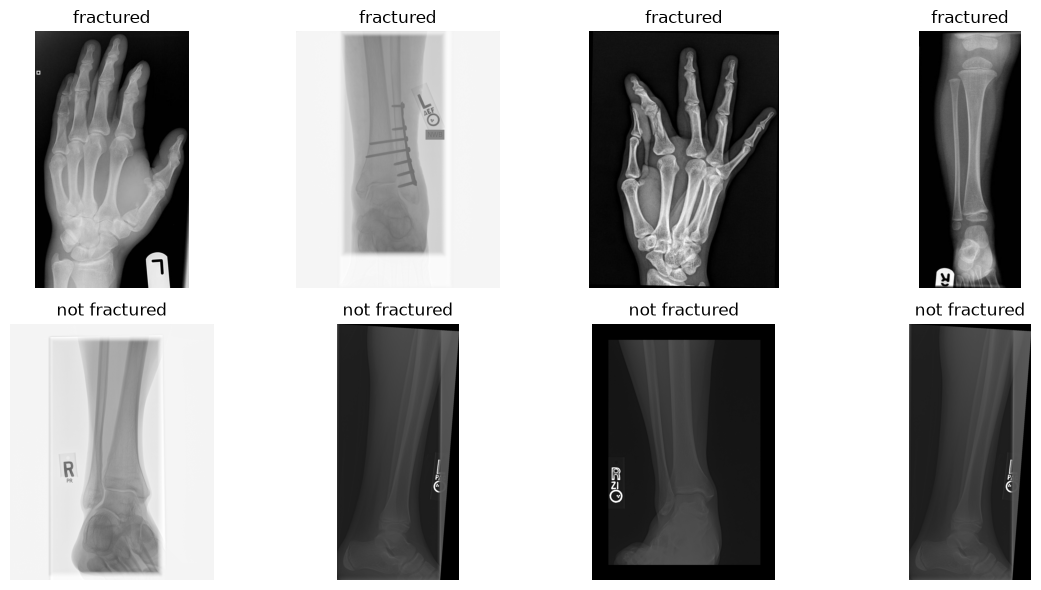

In [4]:
from tensorflow.keras.utils import load_img

classes = ["fractured", "not fractured"]

plt.figure(figsize=(12, 6))

plot_index = 1

for class_name in classes:
    class_path = os.path.join(train_path, class_name)

    for i in range(4):
        image_name = os.listdir(class_path)[i]
        image_path = os.path.join(class_path, image_name)

        img = load_img(image_path)

        plt.subplot(2, 4, plot_index)
        plt.imshow(img, cmap="gray")
        plt.title(class_name)
        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.show()

In [5]:
print("Train classes:",os.listdir(train_path))
print("Validation classes:", os.listdir(validation_path))
print("Test classes:", os.listdir(test_path))

Train classes: ['fractured', 'not fractured']
Validation classes: ['fractured', 'not fractured']
Test classes: ['fractured', 'not fractured']


In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

training_set = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    color_mode="grayscale",
    batch_size=32,
    class_mode="binary",
    shuffle=True
)

Found 9240 images belonging to 2 classes.


In [7]:
validation_datagen = ImageDataGenerator(
    rescale=1./255
)

validation_set = validation_datagen.flow_from_directory(
    validation_path,
    target_size=(224, 224),
    color_mode="grayscale",
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 823 images belonging to 2 classes.


In [8]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

test_set = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    color_mode="grayscale",
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 500 images belonging to 2 classes.


In [9]:
print("Training images:", training_set.samples)
print("Validation images:", validation_set.samples)
print("Test images:", test_set.samples)

print("Class indices:", training_set.class_indices)

Training images: 9240
Validation images: 823
Test images: 500
Class indices: {'fractured': 0, 'not fractured': 1}


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout
model = Sequential()


BLOCK of cnn


In [11]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D,
    BatchNormalization, Dropout,
    GlobalAveragePooling2D, Dense
)
model = Sequential([
    
    Input(shape=(224, 224, 1)),

    
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.20),


    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.30),

    
    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.40),


    Dense(1, activation='sigmoid')
])

model.summary()

I0000 00:00:1788803318.362644    1670 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 304,481 (1.16 MB)

 Trainable params: 303,777 (1.16 MB)

 Non-trainable params: 704 (2.75 KB)

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7
)

In [14]:
history = model.fit(
    training_set,
    validation_data=validation_set,
    epochs=20,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/20


I0000 00:00:1788803321.384067    1670 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1788803324.190334    2436 service.cc:153] XLA service 0x7c7660050300 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788803324.190363    2436 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.4.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.25.1)
I0000 00:00:1788803324.266596    2436 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788803324.716878    2436 cuda_dnn.cc:461] Loaded cuDNN version 92501
I0000 00:00:1788803324.830426    2436 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5070__.66
I0000 00:00:1788803334.183464    2436 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe th

211/289 ━━━━━━━━━━━━━━━━━━━━ 56s 720ms/step - accuracy: 0.7118 - loss: 0.5916

I0000 00:00:1788803496.720551    2435 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5070__.66


289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 771ms/step - accuracy: 0.7185 - loss: 0.5765

/home/srijan_yadav07/medical-env/lib/python3.12/site-packages/PIL/Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


289/289 ━━━━━━━━━━━━━━━━━━━━ 272s 865ms/step - accuracy: 0.7185 - loss: 0.5765 - val_accuracy: 0.5905 - val_loss: 0.8976 - learning_rate: 1.0000e-04
Epoch 2/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 79s 272ms/step - accuracy: 0.7846 - loss: 0.4808 - val_accuracy: 0.6051 - val_loss: 0.7816 - learning_rate: 1.0000e-04
Epoch 3/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 88s 303ms/step - accuracy: 0.8200 - loss: 0.4090 - val_accuracy: 0.6792 - val_loss: 0.6350 - learning_rate: 1.0000e-04
Epoch 4/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 101s 348ms/step - accuracy: 0.8501 - loss: 0.3597 - val_accuracy: 0.6999 - val_loss: 0.8352 - learning_rate: 1.0000e-04
Epoch 5/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 101s 348ms/step - accuracy: 0.8785 - loss: 0.3005 - val_accuracy: 0.8141 - val_loss: 0.4931 - learning_rate: 1.0000e-04
Epoch 6/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 98s 339ms/step - accuracy: 0.8956 - loss: 0.2747 - val_accuracy: 0.8287 - val_loss: 0.4574 - learning_rate: 1.0000e-04
Epoch 7/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 93s 320ms/step

In [15]:
test_loss, test_accuracy = model.evaluate(test_set)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.8940 - loss: 0.2634 
Test Loss: 0.2634070813655853
Test Accuracy: 0.8939999938011169


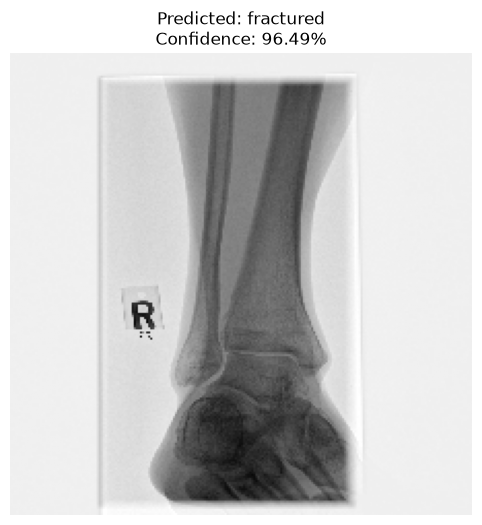

Image: not fractured/4.png
Prediction: fractured
Confidence: 96.49%


In [17]:
from tensorflow.keras.utils import load_img, img_to_array
image_name = "not fractured/4.png"

image_path = os.path.join(test_path, image_name)

img = load_img(image_path, target_size=(224, 224), color_mode="grayscale")
img_array = img_to_array(img) / 255.0
input_image = np.expand_dims(img_array, axis=0)

prediction = model.predict(input_image, verbose=0)[0][0]

if prediction >= 0.5:
    predicted_class = "not fractured"
    confidence = prediction
else:
    predicted_class = "fractured"
    confidence = 1 - prediction

plt.figure(figsize=(6, 6))
plt.imshow(img_array.squeeze(), cmap="gray")
plt.axis("off")
plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence * 100:.2f}%")
plt.show()

print("Image:", image_name)
print("Prediction:", predicted_class)
print(f"Confidence: {confidence * 100:.2f}%")

In [18]:
print(test_set.class_indices)
print(test_set.image_shape)
print(test_set.class_mode)
print("Raw prediction:", prediction)
print("Actual:", class_name)

{'fractured': 0, 'not fractured': 1}
(224, 224, 1)
binary
Raw prediction: 0.03512633
Actual: not fractured


In [20]:
model.save("/mnt/d/Medical-Image-Diagnosis/models/bone_fracture_scratch.keras")
print("Model saved successfully")

Model saved successfully
